In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
sys.path.insert(1, '../')

In [2]:
import pyFBS

from scipy import sparse
from xarray import DataArray
from scipy.sparse.linalg import eigsh
import numpy as np

import pyvista as pv
import pyansys

from pyFBS.utility import *


In [3]:
stl = r'C:\Users\tomaz.bregar\Desktop\git_projects\svd_decoupling\MK_files\AB_n.stl'
xlsx = r'C:\Users\tomaz.bregar\Desktop\git_projects\svd_decoupling\MK_files\GEO_SIM_v3.xlsx'

In [4]:
full_file = r'C:\Users\tomaz.bregar\Desktop\git_projects\svd_decoupling\MK_files\AB\file.full'
ress_file = r'C:\Users\tomaz.bregar\Desktop\git_projects\svd_decoupling\MK_files\AB\file.rst'

MK = pyFBS.MK_model(ress_file,full_file,no_modes = 100)

In [5]:
view3D = pyFBS.display.view3D()
view3D.add_stl(stl,name = "engine_mount",color = "#8FB1CC",opacity = 0.2)

In [6]:
point_cloud = pv.PolyData(MK.nodes*1000)
mesh_actor = view3D.plot.add_mesh(point_cloud,scalars = np.zeros(point_cloud.points.shape[0]) ,color = "k",name = "mesh",cmap = "viridis",render_points_as_spheres = True,point_size=1.5)
pts = point_cloud.points.copy()

In [7]:
# Priprava animacije oblike
select_mode = 50      
relative_scale = 30

#kreairanje animacije
_modeshape = np.zeros_like(MK.nodes)
for ref,mode in zip(MK.dof_ref,MK.eigen_vec[:,select_mode]):
    _modeshape[ref[0]-1,ref[1]] = mode

#samo priprava vsega za onimacijo v pyFBSu
mode_dict = dict()
mode_dict["animation_pts"] = mode_animation(_modeshape,relative_scale,no_points = 60)
mode_dict["mesh"] = point_cloud
mode_dict["or_pts"] = pts
mode_dict["scalars"] = True
mode_dict["fps"] = 30

#dodajanje animacije v okno
view3D.add_modeshape(mode_dict,run_animation = True)

In [8]:
df_imp = pd.read_excel(xlsx, sheet_name='Impacts_AB')
view3D.show_imp(df_imp)
#df_imp

In [9]:
df_chn = pd.read_excel(xlsx, sheet_name='Channels_AB')
view3D.show_chn(df_chn)
#df_chn

In [10]:
MK.FRF_synth(df_chn,df_imp)

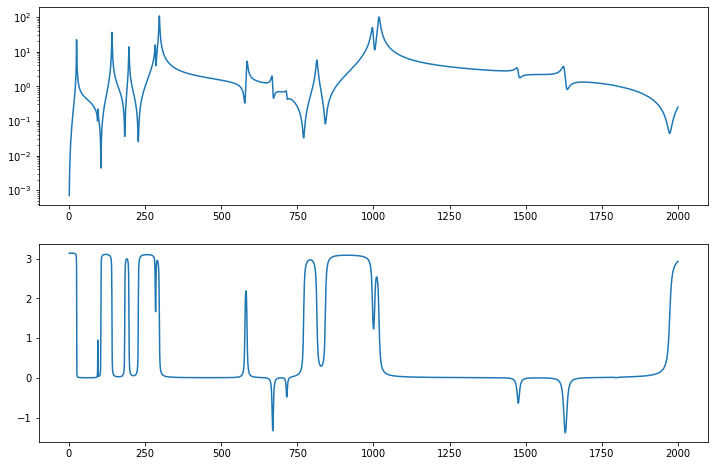

In [11]:
plt.figure(figsize = (12,8))
plt.subplot(211)
plt.semilogy(MK.freq,np.abs(MK.FRF[0,0]))
#plt.semilogy(freq,np.abs(FRF[-2,-1]),'--')

plt.subplot(212)
plt.plot(MK.freq,np.angle(MK.FRF[0,0]))
#plt.plot(freq,np.angle(FRF[2,0]),'--')

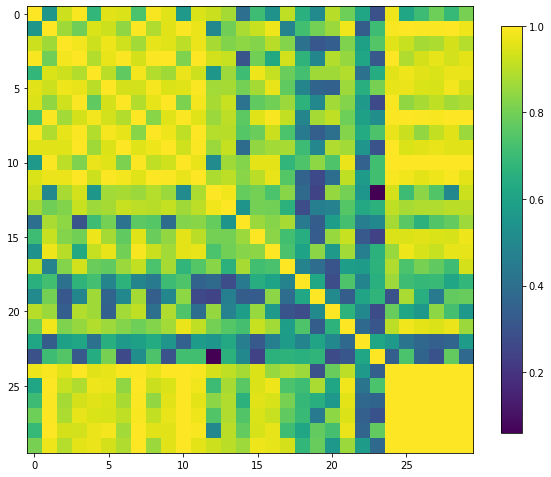

In [12]:
def coh_frf(h_num, h_exp,check = False):
    """
    :param h_num: numerični kompleksni vektor FRF
    :param h_exp: eksperimentalni kompleksni vektor FRF
    
    :return: vrednost coherence kriterija
    """
    
    h_numk = np.conjugate(h_num)
    h_expk = np.conjugate(h_exp)
    
    def vector(h_, h_K):
        """
        :param h_: kompleksni vektor FRF
        :param h_K: konjugirani kompleksni vektor FRF
        
        :return: vektorski produkt
        """
        
        vec = np.dot(h_, h_K)
        return vec

    coh = (h_num + h_exp)
    
    coh = np.abs(vector((h_num + h_exp), (h_numk + h_expk)))  / 2 / (vector(h_numk, h_num)+vector(h_expk, h_exp))
    coh_abs = np.abs(coh)
    
    if check:
        return coh,coh_abs
    else:
        return coh_abs
    
Y_coh = np.zeros((30,30))

for i in range(30):
    for j in range(30):
        Y_coh[i,j] = coh_frf(MK.FRF[i,j], MK.FRF[j,i])


plt.figure(figsize = (10,10))
plt.imshow(Y_coh)
plt.colorbar(shrink =.75);


In [13]:
MK.add_noise()

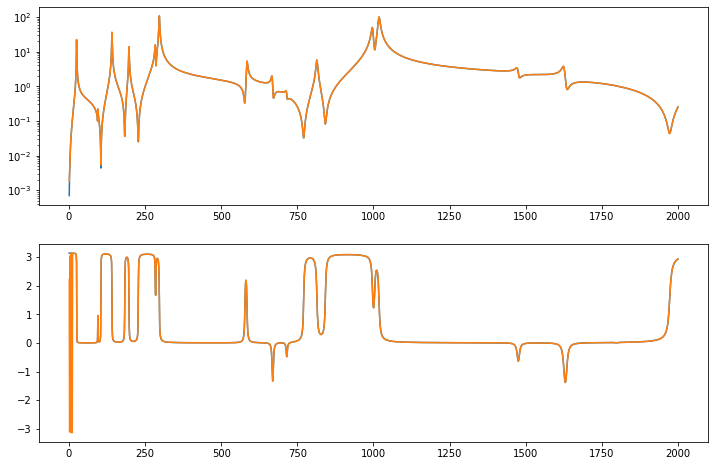

In [15]:
plt.figure(figsize = (12,8))
plt.subplot(211)
plt.semilogy(MK.freq,np.abs(MK.FRF[0,0]))
plt.semilogy(MK.freq,np.abs(MK.FRF_noise[0,0]))

#plt.semilogy(freq,np.abs(FRF[-2,-1]),'--')

plt.subplot(212)
plt.plot(MK.freq,np.angle(MK.FRF[0,0]))
plt.plot(MK.freq,np.angle(MK.FRF_noise[0,0]))
#plt.plot(freq,np.angle(FRF[2,0]),'--')